In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
DATASET_PATH = "/content/drive/MyDrive/Diverse Fetal Head Images"
print(os.listdir(DATASET_PATH))

['Test-Dataset-Segmentation', 'SegmentationClass', 'Orginal_train_images_to_959_661']


In [ ]:
!pip install -q segmentation-models-pytorch albumentations
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
print('PyTorch:', torch.__version__)
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.0 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
import os
IMAGES_DIR  = '/content/drive/MyDrive/Diverse Fetal Head Images/Orginal_train_images_to_959_661'
MASKS_DIR   = '/content/drive/MyDrive/Diverse Fetal Head Images/SegmentationClass'
CHECKPT_DIR = '/content/drive/MyDrive/unet_fetal_checkpoints'
os.makedirs(CHECKPT_DIR, exist_ok=True)
assert os.path.isdir(IMAGES_DIR), f'Images folder not found: {IMAGES_DIR}'
assert os.path.isdir(MASKS_DIR),  f'Masks folder not found: {MASKS_DIR}'
imgs  = sorted(os.listdir(IMAGES_DIR))
masks = sorted(os.listdir(MASKS_DIR))
print(f'Found {len(imgs)} images and {len(masks)} masks')
print('Sample images:', imgs[:3])
print('Sample masks :', masks[:3])

Found 999 images and 999 masks
Sample images: ['000_HC.png', '001_HC.png', '002_HC.png']
Sample masks : ['000_HC.png', '001_HC.png', '002_HC.png']


Sample 1 | unique values: [0 1]
Sample 2 | unique values: [0 1]
Sample 3 | unique values: [0 1]


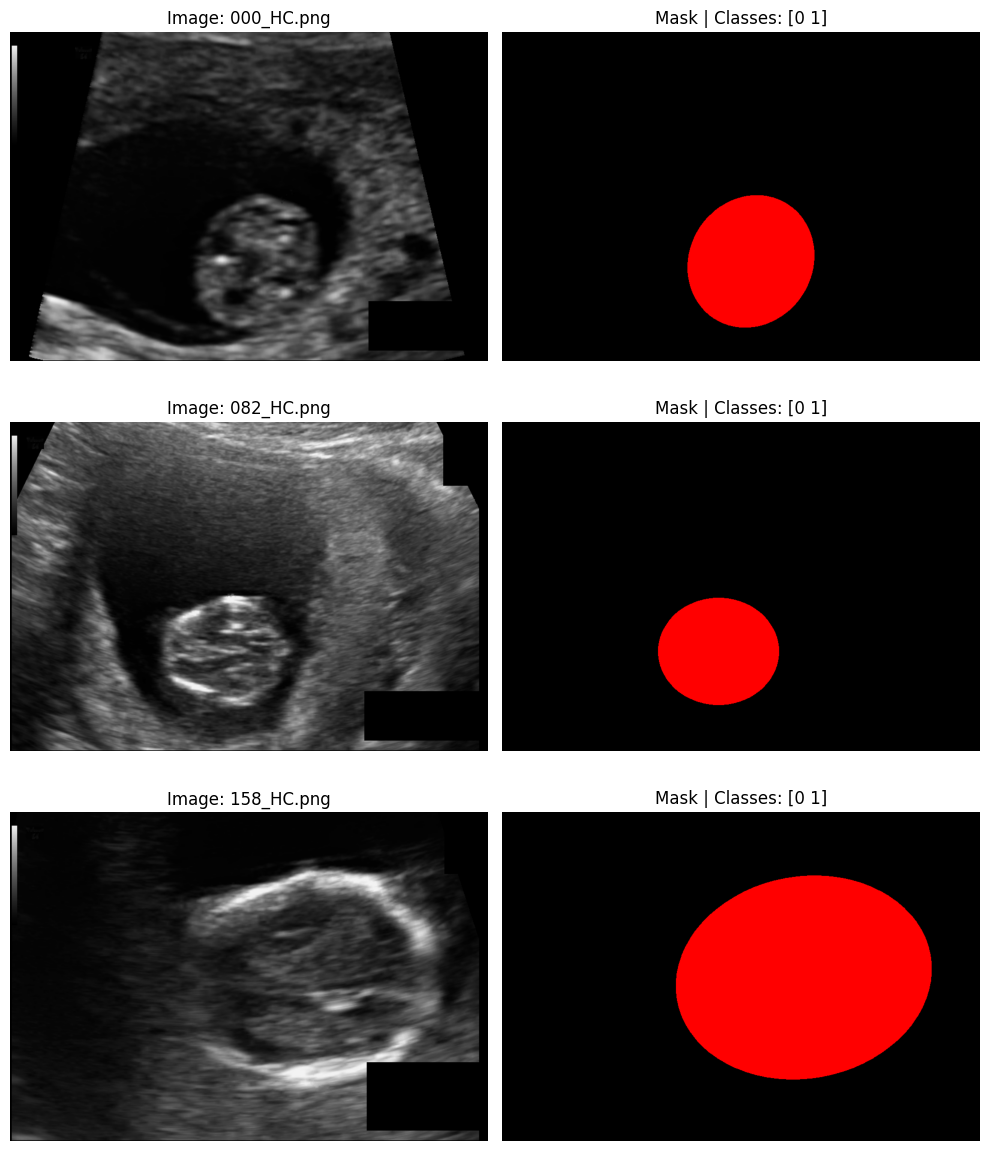

In [ ]:

NUM_CLASSES = 2
CLASS_COLORS = {
    0: (0,   0,   0),    # Black = Background
    1: (255, 0,   0),    # Red   = Fetal Head
}
def colorize_mask(mask):
    if mask.ndim == 3:
        mask = mask[:, :, 0]
    h, w = mask.shape
    color = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, rgb in CLASS_COLORS.items():
        color[mask == cls] = rgb
    return color
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
for i in range(3):
    img_path  = os.path.join(IMAGES_DIR, imgs[i*100])
    stem      = os.path.splitext(imgs[i*100])[0]
    mask_name = stem + '.png'
    mask_path = os.path.join(MASKS_DIR, mask_name)
    if not os.path.exists(mask_path):
        mask_path = os.path.join(MASKS_DIR, masks[i*100])
    img  = np.array(Image.open(img_path).convert('RGB'))
    mask = np.array(Image.open(mask_path))
    if mask.ndim == 3:
        mask = (mask[:, :, 0] > 127).astype(np.uint8)
    unique_classes = np.unique(mask)
    print(f'Sample {i+1} | unique values: {unique_classes}')
    axes[i,0].imshow(img)
    axes[i,0].set_title(f'Image: {imgs[i*100]}')
    axes[i,0].axis('off')

    axes[i,1].imshow(colorize_mask(mask))
    axes[i,1].set_title(f'Mask | Classes: {unique_classes}')
    axes[i,1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
class FetalHeadDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img  = np.array(Image.open(self.image_paths[idx]).convert('RGB'))
        mask = np.array(Image.open(self.mask_paths[idx]))
        if mask.ndim == 3:
            mask = (mask[:, :, 0] > 127).astype(np.uint8)
        else:
            mask = (mask > 127).astype(np.uint8)
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented['image']
            mask = augmented['mask']
        return img, mask.long()

In [ ]:
def find_mask_for_image(img_name, masks_dir, mask_list):
    stem = os.path.splitext(img_name)[0]
    for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
        candidate = stem + ext
        if candidate in mask_list:
            return os.path.join(masks_dir, candidate)
    return None
image_files = sorted([f for f in os.listdir(IMAGES_DIR)
                       if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))])
mask_files  = set(os.listdir(MASKS_DIR))
paired_images, paired_masks = [], []
for img_name in image_files:
    mask_path = find_mask_for_image(img_name, MASKS_DIR, mask_files)
    if mask_path:
        paired_images.append(os.path.join(IMAGES_DIR, img_name))
        paired_masks.append(mask_path)
print(f'Paired samples: {len(paired_images)}')
assert len(paired_images) > 0, 'No pairs found! Check your paths or file naming.'
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    paired_images, paired_masks, test_size=0.2, random_state=42
)
print(f'Train: {len(train_imgs)} | Val: {len(val_imgs)}')

Paired samples: 999
Train: 799 | Val: 200


In [ ]:
IMG_SIZE   = 256
BATCH_SIZE = 8
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
train_dataset = FetalHeadDataset(train_imgs, train_masks, transform=train_transform)
val_dataset   = FetalHeadDataset(val_imgs,   val_masks,   transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f'Image size: {IMG_SIZE}x{IMG_SIZE}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Image size: 256x256
Train batches: 100 | Val batches: 25


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = 1,
    activation      = None,
)
model = model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Trainable parameters: 24,436,369


In [ ]:
bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode='binary')
def criterion(preds, targets):
    targets_f = targets.float().unsqueeze(1)   # (B, 1, H, W)
    return bce_loss(preds, targets_f) + dice_loss(preds, targets_f)
print('Binary loss ready.')

Binary loss ready.


In [ ]:
def compute_metrics(preds, targets):
    preds    = torch.sigmoid(preds)
    preds_b  = (preds > 0.5).float().squeeze(1)   # (B, H, W)
    targets_f = targets.float()
    intersection = (preds_b * targets_f).sum().float()
    union        = preds_b.sum() + targets_f.sum()
    dice = (2 * intersection + 1e-6) / (union + 1e-6)
    iou  = (intersection + 1e-6) / (union - intersection + 1e-6)
    return iou.item(), dice.item()

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr      = 3e-4,
    epochs      = 50,
    steps_per_epoch = len(train_loader),
    pct_start   = 0.1,   # 10% warmup
)
print('Optimizer and scheduler ready.')

Optimizer and scheduler ready.


In [ ]:
NUM_EPOCHS   = 35
best_val_iou = 0.0
history      = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)          # (B, 1, H, W)
        loss    = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    model.eval()
    val_loss = 0.0
    val_ious, val_dices = [], []
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, masks)
            val_loss += loss.item()
            iou, dice = compute_metrics(outputs, masks)
            val_ious.append(iou)
            val_dices.append(dice)
    val_loss  /= len(val_loader)
    mean_iou   = np.mean(val_ious)
    mean_dice  = np.mean(val_dices)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(mean_iou)
    history['val_dice'].append(mean_dice)
    if mean_iou > best_val_iou:
        best_val_iou = mean_iou
        torch.save(model.state_dict(), os.path.join(CHECKPT_DIR, 'best_unet.pth'))
        saved = ' Saved'
    else:
        saved = ''
    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
          f'Val IoU: {mean_iou:.4f} | Val Dice: {mean_dice:.4f} {saved}')
print(f'\nBest Val IoU: {best_val_iou:.4f}')
print(f'Model saved to: {CHECKPT_DIR}/best_unet.pth')

Epoch [01/35] Train Loss: 1.0697 | Val Loss: 0.7357 | Val IoU: 0.7455 | Val Dice: 0.8536  Saved
Epoch [02/35] Train Loss: 0.5489 | Val Loss: 0.3484 | Val IoU: 0.8936 | Val Dice: 0.9436  Saved
Epoch [03/35] Train Loss: 0.2882 | Val Loss: 0.1954 | Val IoU: 0.9361 | Val Dice: 0.9670  Saved
Epoch [04/35] Train Loss: 0.1814 | Val Loss: 0.1491 | Val IoU: 0.9308 | Val Dice: 0.9641 
Epoch [05/35] Train Loss: 0.1426 | Val Loss: 0.1069 | Val IoU: 0.9413 | Val Dice: 0.9697  Saved
Epoch [06/35] Train Loss: 0.1287 | Val Loss: 0.1020 | Val IoU: 0.9375 | Val Dice: 0.9677 
Epoch [07/35] Train Loss: 0.1200 | Val Loss: 0.1004 | Val IoU: 0.9360 | Val Dice: 0.9668 
Epoch [08/35] Train Loss: 0.1064 | Val Loss: 0.0893 | Val IoU: 0.9409 | Val Dice: 0.9695 
Epoch [09/35] Train Loss: 0.0944 | Val Loss: 0.0850 | Val IoU: 0.9402 | Val Dice: 0.9691 
Epoch [10/35] Train Loss: 0.0890 | Val Loss: 0.0772 | Val IoU: 0.9475 | Val Dice: 0.9730  Saved
Epoch [11/35] Train Loss: 0.0854 | Val Loss: 0.0749 | Val IoU: 0.9478 

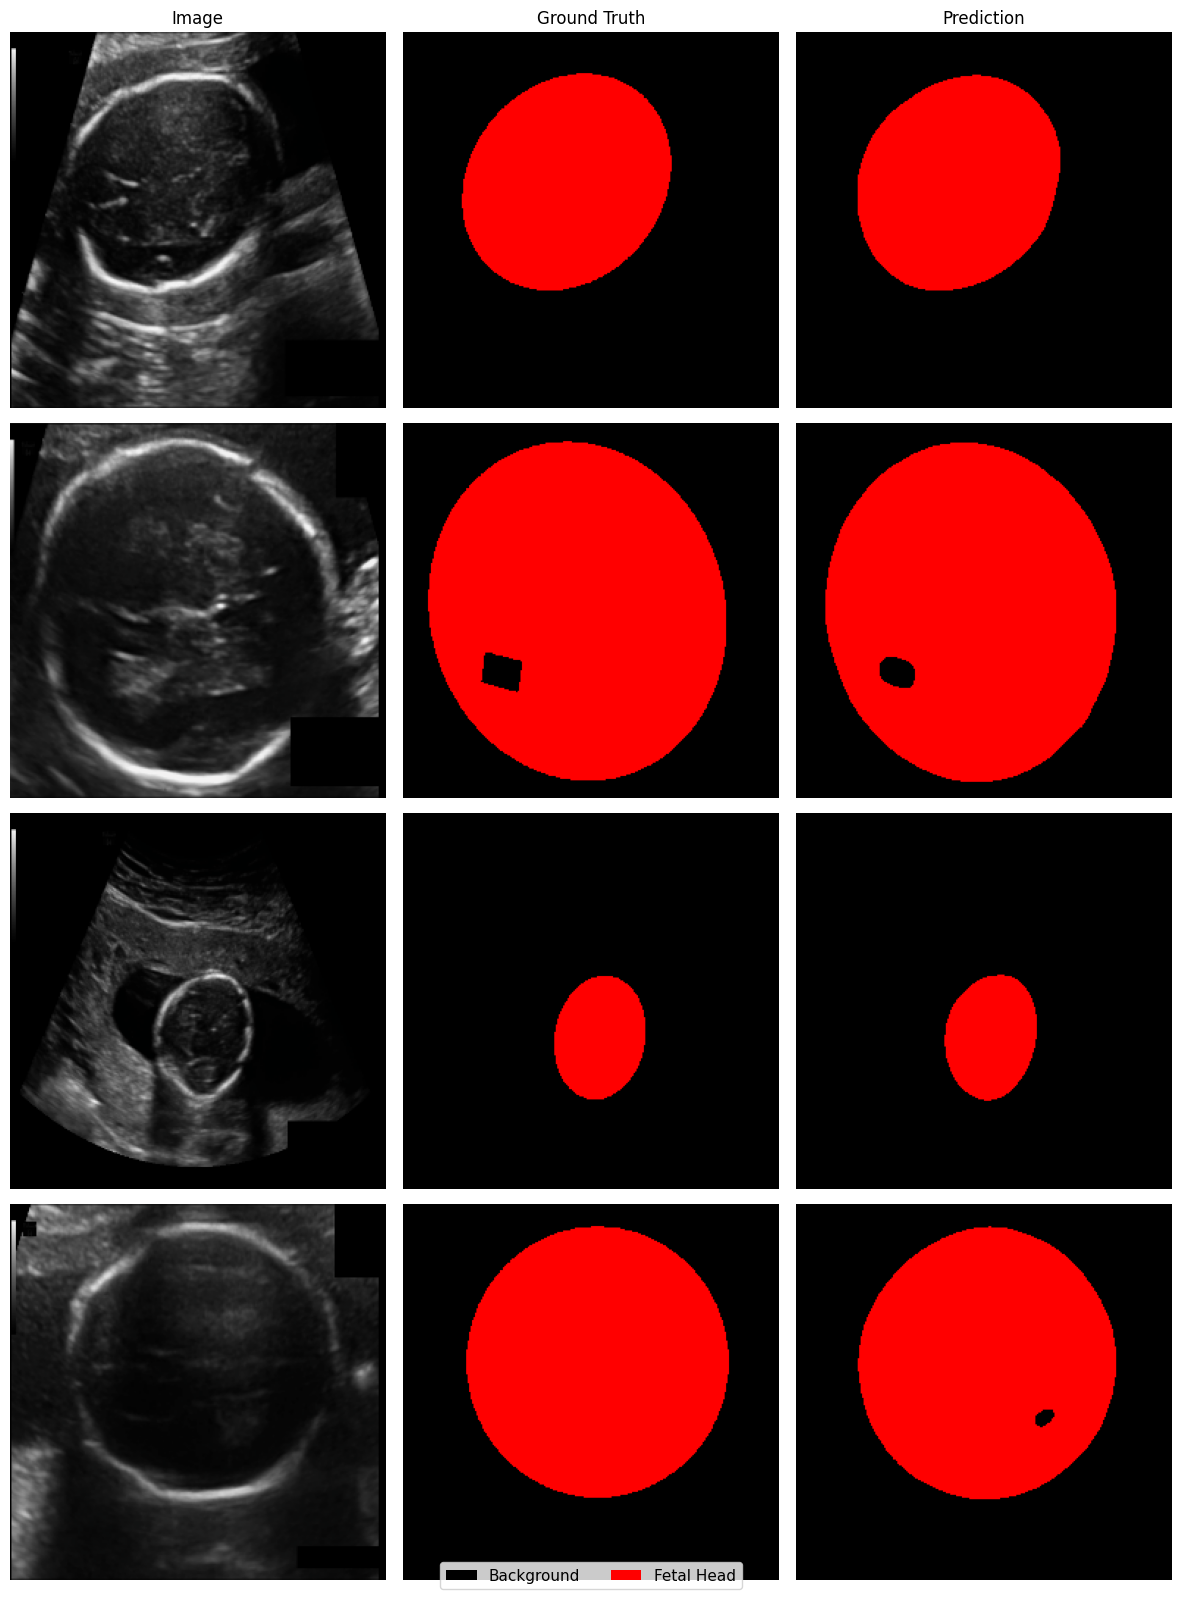

In [ ]:
model.load_state_dict(torch.load(os.path.join(CHECKPT_DIR, 'best_unet.pth'), map_location=DEVICE))
model.eval()
mean_n = np.array([0.485, 0.456, 0.406])
std_n  = np.array([0.229, 0.224, 0.225])
def denormalize(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * std_n + mean_n, 0, 1)
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
axes[0,0].set_title('Image')
axes[0,1].set_title('Ground Truth')
axes[0,2].set_title('Prediction')
sample_ds = FetalHeadDataset(val_imgs[:4], val_masks[:4], transform=val_transform)
for i in range(4):
    img_t, mask_t = sample_ds[i]
    with torch.no_grad():
        pred = torch.sigmoid(
            model(img_t.unsqueeze(0).to(DEVICE))
        ).squeeze().cpu().numpy()
        pred = (pred > 0.5).astype(np.uint8)
    gt_color   = np.zeros((*mask_t.shape, 3), dtype=np.uint8)
    pred_color = np.zeros((*pred.shape,   3), dtype=np.uint8)
    gt_color  [mask_t.numpy() == 1] = (255, 0, 0)
    pred_color[pred            == 1] = (255, 0, 0)
    axes[i,0].imshow(denormalize(img_t))
    axes[i,0].axis('off')
    axes[i,1].imshow(gt_color)
    axes[i,1].axis('off')
    axes[i,2].imshow(pred_color)
    axes[i,2].axis('off')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='black', label='Background'),
    Patch(facecolor='red',   label='Fetal Head'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPT_DIR, 'final_predictions.png'), dpi=100)
plt.show()

In [3]:
!pip install -q kaggle

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"priyankshusinha","key":"732023c8ed2c06dfb59695fc14733e9f"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!pip install -q kaggle
!kaggle datasets download -d orvile/fetal-abdominal-structures-segmentation-dataset

Dataset URL: https://www.kaggle.com/datasets/orvile/fetal-abdominal-structures-segmentation-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.07G/1.07G [00:30<00:00, 38.3MB/s]



In [6]:
!unzip -q fetal-abdominal-structures-segmentation-dataset.zip -d dataset

In [7]:
import os
os.listdir("dataset")

['dataset',
 'Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images']

In [8]:
for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images
dataset/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images
dataset/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images
dataset/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/ARRAY_FORMAT
dataset/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/IMAGES


In [ ]:
BASE = "dataset/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Stuctures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images"

IMG_DIR = BASE + "/IMAGES"
MASK_DIR = BASE + "/ARRAY_FORMAT"

In [10]:
import os

print(len(os.listdir(IMG_DIR)))
print(len(os.listdir(MASK_DIR)))

1588
1588


In [11]:
print(sorted(os.listdir(IMG_DIR))[:5])
print(sorted(os.listdir(MASK_DIR))[:5])

['P0100_IMG1.png', 'P0100_IMG2.png', 'P0100_IMG3.png', 'P0100_IMG4.png', 'P0100_IMG5.png']
['P0100_IMG1.npy', 'P0100_IMG2.npy', 'P0100_IMG3.npy', 'P0100_IMG4.npy', 'P0100_IMG5.npy']


In [12]:
img_name = sorted(os.listdir(IMG_DIR))[0]
mask_name = sorted(os.listdir(MASK_DIR))[0]

print(img_name, mask_name)

P0100_IMG1.png P0100_IMG1.npy


In [13]:
print(os.path.join(MASK_DIR, mask_name))

dataset/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/Fetal Abdominal Structures Segmentation Dataset Using Ultrasonic Images/ARRAY_FORMAT/P0100_IMG1.npy


In [14]:
print(os.path.exists(os.path.join(MASK_DIR, mask_name)))

True


In [15]:
import numpy as np
sample_mask = np.load(os.path.join(MASK_DIR, mask_name), allow_pickle=True)
print(type(sample_mask))
print(np.unique(sample_mask))

<class 'numpy.ndarray'>
[{'image': array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        ...,

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]], dtype=uint8), 'structures': {'artery': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],

In [16]:
data = np.load(os.path.join(MASK_DIR, mask_name), allow_pickle=True).item()
structures = data['structures']
combined_mask = (
    structures['artery'] +
    structures['liver'] +
    structures['stomach'] +
    structures['vein']
)

combined_mask = (combined_mask > 0).astype(np.uint8)

print(combined_mask.shape)
print(np.unique(combined_mask))  # should be [0,1]

(768, 1024)
[0 1]


In [ ]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import os
class AbdomenDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_name = self.images[idx]
        mask_name = self.masks[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        raw = np.load(os.path.join(self.mask_dir, mask_name), allow_pickle=True)
        data = raw.item()
        structures = data['structures']
        mask = (
            structures['artery'] +
            structures['liver'] +
            structures['stomach'] +
            structures['vein']
        )
        mask = (mask > 0).astype(np.uint8)

        # ---- Resize (IMPORTANT) ----
        image = cv2.resize(image, (256, 256), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        # ---- Normalize ----
        image = image / 255.0

        # ---- Add channel dimension ----
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [18]:
dataset = AbdomenDataset(IMG_DIR, MASK_DIR)
img, mask = dataset[0]
print(img.shape)   # (1, 256, 256)
print(mask.shape)  # (1, 256, 256)

torch.Size([1, 256, 256])
torch.Size([1, 256, 256])


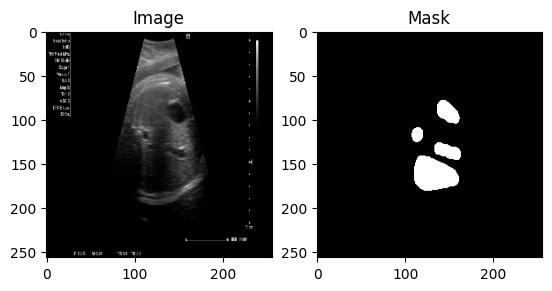

In [19]:
import matplotlib.pyplot as plt
plt.subplot(1,2,1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Image")
plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Mask")
plt.show()

In [20]:
mask_np = mask.squeeze().cpu().numpy()
import cv2
import numpy as np
mask_np = (mask_np > 0).astype(np.uint8)
kernel = np.ones((15,15), np.uint8)
mask_np = cv2.morphologyEx(mask_np, cv2.MORPH_CLOSE, kernel)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_np)
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
mask_np = (labels == largest_label).astype(np.uint8)
mask = torch.tensor(mask_np).unsqueeze(0).float()

In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

for img, mask in train_loader:
    print(img.shape)   # (B,1,256,256)
    print(mask.shape)
    break

torch.Size([8, 1, 256, 256])
torch.Size([8, 1, 256, 256])


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)
        d4 = self.down4(p3)
        p4 = self.pool4(d4)
        bn = self.bottleneck(p4)
        u4 = self.up4(bn)
        u4 = torch.cat([u4, d4], dim=1)
        u4 = self.conv4(u4)
        u3 = self.up3(u4)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)
        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)
        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)
        return self.final(u1)

In [23]:
import torch.nn.functional as F

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    return 1 - (2. * intersection + smooth) / (union + smooth)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for img, mask in train_loader:
        img = img.to(device)
        mask = mask.to(device)
        pred = model(img)
        loss = dice_loss(pred, mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.09868839398101346
Epoch 2, Loss: 0.0977605940708563
Epoch 3, Loss: 0.09355665571126506
Epoch 4, Loss: 0.09110464043353671
Epoch 5, Loss: 0.08728128222364877
Epoch 6, Loss: 0.08583094486639128
Epoch 7, Loss: 0.0838710015742623
Epoch 8, Loss: 0.08312862811975144
Epoch 9, Loss: 0.0826558297003933
Epoch 10, Loss: 0.07962958447298213
Epoch 11, Loss: 0.07876065777773833
Epoch 12, Loss: 0.07709355719724492
Epoch 13, Loss: 0.07457754929461072
Epoch 14, Loss: 0.07489883660072058
Epoch 15, Loss: 0.07475343481380137
Epoch 16, Loss: 0.07527521866649839
Epoch 17, Loss: 0.07230656410581503
Epoch 18, Loss: 0.07152849046429198
Epoch 19, Loss: 0.0702782545856495
Epoch 20, Loss: 0.07024815963141283


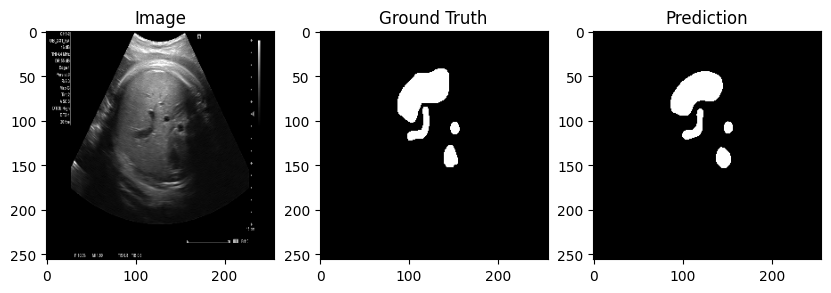

In [29]:
model.eval()
img, mask = dataset[10]
with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
pred = pred.squeeze().cpu().numpy()
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title("Image")
plt.subplot(1,3,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.subplot(1,3,3)
plt.imshow(pred, cmap='gray')
plt.title("Prediction")
plt.show()

In [30]:
model.eval()
img, gt = dataset[10]
with torch.no_grad():
    p = model(img.unsqueeze(0).to(device))
    p = torch.sigmoid(p)
    p = (p > 0.5).float()
pred = p.squeeze().cpu().numpy()

In [31]:
import cv2
import numpy as np
m = (pred > 0).astype(np.uint8)
kernel = np.ones((7,7), np.uint8)
m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(m)
if num_labels > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    m = (labels == largest).astype(np.uint8)

In [32]:
contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)
ellipse = cv2.fitEllipse(cnt)
(_, axes, _) = ellipse
a = max(axes)
b = min(axes)

In [33]:
AC_pixels = np.pi * (a + b) / 2
pixel_spacing = 0.1
AC_mm = AC_pixels * pixel_spacing

In [34]:
GA = 24
def classify_ac(ac, ga):
    expected = 10 * ga
    if ac < 0.9 * expected:
        return "SGA risk"
    elif ac > 1.1 * expected:
        return "LGA risk"
    else:
        return "Normal"
result = classify_ac(AC_mm, GA)
print("AC (mm):", AC_mm)
print("Assessment:", result)

AC (mm): 20.066473666370854
Assessment: SGA risk


In [ ]:
def process_abdomen(image_path, model, device):
    import cv2, torch, numpy as np
    # ---- load image ----
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (256,256)) / 255.0
    img_tensor = torch.tensor(img_resized).unsqueeze(0).unsqueeze(0).float().to(device)
    # ---- prediction ----
    model.eval()
    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()
    pred = pred.squeeze().cpu().numpy()
    # ---- clean mask ----
    kernel = np.ones((7,7), np.uint8)
    mask = cv2.morphologyEx(pred.astype(np.uint8), cv2.MORPH_CLOSE, kernel)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest).astype(np.uint8)
    # ---- ellipse ----
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(contours, key=cv2.contourArea)
    ellipse = cv2.fitEllipse(cnt)
    (_, axes, _) = ellipse
    a, b = max(axes), min(axes)
    AC_pixels = np.pi * (a + b) / 2
    # ---- approximate mm ----
    pixel_spacing = 0.7
    AC_mm = AC_pixels * pixel_spacing
    return {
        "AC_pixels": AC_pixels,
        "AC_mm": AC_mm,
        "ellipse": ellipse,
        "mask": mask
    }

In [36]:
for i in range(5):
    img_path = os.path.join(IMG_DIR, sorted(os.listdir(IMG_DIR))[i])
    out = process_abdomen(img_path, model, device)
    print(out["AC_mm"])

95.11263617826997
124.54905158751076
123.95835153877073
118.44250716411244
120.9102699944837


In [37]:
torch.save(model.state_dict(), "unet_abdomen.pth")